In [ ]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt

import prism

from imagematerials.factory import ModelFactory
from imagematerials.maintenance import Maintenance
from imagematerials.model import (
    GenericMaterials,
    GenericStocks,
    MaterialIntensities
)
from imagematerials.vehicles.battery import ElectricVehicleBatteries, BatteryMaterials, ElectricVehicleBatteries_test
from imagematerials.preprocessing import get_preprocessing_data

In [2]:
vhc_sector = get_preprocessing_data("vehicles", Path("..", "data", "raw"), 
                                    climate_policy_scenario_dir = None, 
                                    circular_economy_scenario_dirs = None)


In [ ]:
time_start = 2020
complete_timeline = prism.Timeline(time_start, 2030, 1)
simulation_timeline = prism.Timeline(2020, 2030, 1)

factory = ModelFactory(
    vhc_sector, complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials
    ).add(ElectricVehicleBatteries_test
    )
model = factory.finish()

warnings.filterwarnings("ignore")
model.simulate(simulation_timeline)

list(model.vehicles)

['lifetimes',
 'battery_materials',
 'battery_shares',
 'material_fractions',
 'battery_weights',
 'stocks',
 'maintenance_material_fractions',
 'knowledge_graph',
 'weights',
 'set_unit_flexible',
 'outflow_by_cohort',
 'inflow',
 'stock_by_cohort',
 'stock_by_cohort_materials',
 'inflow_materials',
 'outflow_by_cohort_materials',
 'inflow_battery',
 'stock_battery',
 'outflow_battery']

In [5]:
model.inflow_battery

<xarray.DataArray (Time: 294, Cohort: 294, Region: 26, battery: 8, Type: 47)> Size: 7GB
array([[[[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
...
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]]]])
Coordinates:
  * Time     (Time) int64 2kB 1807 1808 1809 1810 1811 ... 2097 2098 2099 2100
  * Cohort   (Cohort) int64 2kB 1807 1808 1809 1810 1811 ... 2097 2098 2099 2100
  * Region   (Region) <U2 208B '1' '2' '3' '4' '5' ... '22' '23' '24' '25' '26'
  * battery  (battery) <U16 512B 'LFP' 'LMO/LCO' ... 'NMC' 'NiMH'
  * Type     (Type) <U35 7kB 'Bikes' ... 'Regular Buses - Trolley'

In [19]:
# da = model.inflow_battery.sum(["Region", "Type"])
da = model.stock_battery.sum(["Region", "Type", "Cohort"])

In [20]:
da

<xarray.DataArray (Time: 294, battery: 8)> Size: 19kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
  * Time     (Time) int64 2kB 1807 1808 1809 1810 1811 ... 2097 2098 2099 2100
  * battery  (battery) <U16 512B 'LFP' 'LMO/LCO' ... 'NMC' 'NiMH'

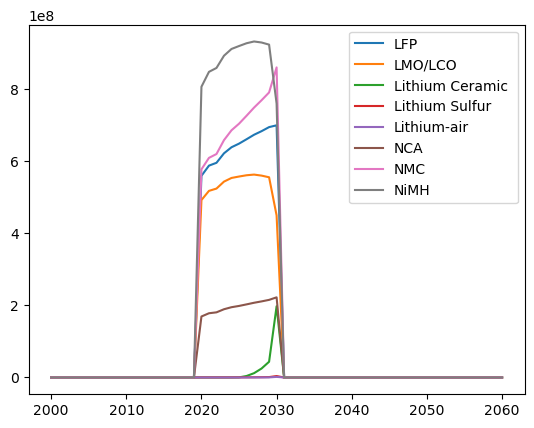

In [21]:

da_plot = da.sel(Time=slice(2000,2060))
fig, ax = plt.subplots()
for b in da_plot.battery.values:
    plt.plot(da_plot.Time, da_plot.sel(battery=b), label=b)
plt.legend()

In [7]:
vhc_sector

In [5]:
time_start = 2020
complete_timeline = prism.Timeline(time_start, 2030, 1)
simulation_timeline = prism.Timeline(2020, 2030, 1)

factory = ModelFactory(
    vhc_sector, complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials
    ).add(BatteryMaterials
    )
model = factory.finish()

warnings.filterwarnings("ignore")
model.simulate(simulation_timeline)

list(model.vehicles)

['lifetimes',
 'battery_materials',
 'battery_shares',
 'material_fractions',
 'battery_weights',
 'stocks',
 'maintenance_material_fractions',
 'knowledge_graph',
 'weights',
 'set_unit_flexible',
 'outflow_by_cohort',
 'inflow',
 'stock_by_cohort',
 'stock_by_cohort_materials',
 'inflow_materials',
 'outflow_by_cohort_materials',
 'inflow_battery_materials',
 'stock_battery_materials',
 'outflow_battery_materials']

In [23]:
# model.battery_weights
model.battery_materials
# model.battery_shares
# model.battery_weights.sel(Type="Medium Freight Trucks - BEV")

<xarray.DataArray (Cohort: 294, material: 14, battery: 8)> Size: 263kB
array([[[0.05      , 0.0374    , 0.1838    , ..., 0.24371619,
         0.0374    , 0.00255   ],
        [0.        , 0.        , 0.02098931, ..., 0.03130767,
         0.07644953, 0.00255   ],
        [0.05      , 0.1003    , 0.0782    , ..., 0.1247216 ,
         0.1003    , 0.01769956],
        ...,
        [0.1408805 , 0.2147    , 0.0053    , ..., 0.0074133 ,
         0.2147    , 0.1       ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.05      , 0.0374    , 0.1838    , ..., 0.24371619,
         0.0374    , 0.00255   ],
        [0.        , 0.        , 0.02098931, ..., 0.03130767,
         0.07644953, 0.00255   ],
        [0.05      , 0.1003    , 0.0782    , ..., 0.1247216 ,
         0.1003    , 0.01769956],
...
        [0.1408805 , 0.2147    , 0.0053    , ..., 0.0074133 ,
         0.2147    , 0.1       ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.05      , 0.0374    , 0.1838    , ..., 0.24371619,
         0.0374    , 0.00255   ],
        [0.        , 0.        , 0.02098931, ..., 0.03130767,
         0.07644953, 0.00255   ],
        [0.05      , 0.1003    , 0.0782    , ..., 0.1247216 ,
         0.1003    , 0.01769956],
        ...,
        [0.1408805 , 0.2147    , 0.0053    , ..., 0.0074133 ,
         0.2147    , 0.1       ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]]])
Coordinates:
  * Cohort    (Cohort) int64 2kB 1807 1808 1809 1810 ... 2097 2098 2099 2100
  * material  (material) <U9 504B 'Aluminium' 'Co' 'Cu' ... 'Steel' 'Ti' 'Wood'
  * battery   (battery) <U16 512B 'LFP' 'LMO/LCO' ... 'NMC' 'NiMH'

# Batteries

TypeError: ElectricVehicleBatteries_test.compute_initial_values() missing 3 required positional arguments: 'inflow', 'stock_by_cohort', and 'outflow_by_cohort'